Dataset Loaded: (20, 18)

High Revenue + High Risk Vendors: 4


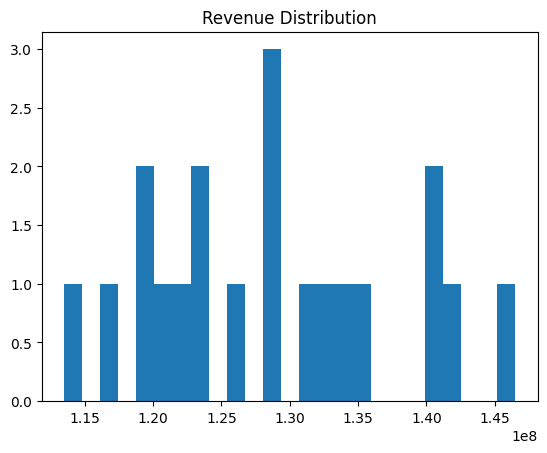


Day 24 Completed Successfully


In [3]:
# ==========================================================
# DAY 24 - REVENUE CONTRIBUTION ANALYSIS
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

# ----------------------------------------------------------
# INPUT / OUTPUT PATHS
# ----------------------------------------------------------

INPUT_FILE = PROJECT_ROOT / "03_processed_data/day23_outputs/demand_analysis_full.csv"
OUTPUT_FOLDER = PROJECT_ROOT / "03_processed_data/day24_outputs"

OUTPUT_FOLDER.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. SAFETY CHECK (risk_score)
# ----------------------------------------------------------

if "risk_score" not in df.columns:

    df["defect_score"] = (
        (df["avg_defect"] - df["avg_defect"].min()) /
        (df["avg_defect"].max() - df["avg_defect"].min())
    )

    df["cost_score"] = (
        (df["avg_cost"] - df["avg_cost"].min()) /
        (df["avg_cost"].max() - df["avg_cost"].min())
    )

    df["risk_score"] = (
        df["defect_score"] * 0.6 +
        df["cost_score"] * 0.4
    )

# ----------------------------------------------------------
# 2. REVENUE ESTIMATION
# ----------------------------------------------------------

MARKUP = 1.3

df["estimated_revenue"] = df["total_quantity"] * df["avg_cost"] * MARKUP
df["estimated_profit"] = df["estimated_revenue"] - (df["total_quantity"] * df["avg_cost"])

# ----------------------------------------------------------
# 3. REVENUE CONTRIBUTION %
# ----------------------------------------------------------

total_revenue = df["estimated_revenue"].sum()

df["revenue_contribution_pct"] = (
    df["estimated_revenue"] / total_revenue
) * 100

# ----------------------------------------------------------
# 4. REVENUE SEGMENTATION
# ----------------------------------------------------------

df["revenue_score"] = (
    (df["estimated_revenue"] - df["estimated_revenue"].min()) /
    (df["estimated_revenue"].max() - df["estimated_revenue"].min())
)

def revenue_category(score):
    if score >= 0.7:
        return "High Revenue"
    elif score >= 0.4:
        return "Medium Revenue"
    else:
        return "Low Revenue"

df["revenue_category"] = df["revenue_score"].apply(revenue_category)

# ----------------------------------------------------------
# 5. HIGH REVENUE + HIGH RISK
# ----------------------------------------------------------

high_rev_risk = df[
    (df["revenue_category"] == "High Revenue") &
    (df["risk_score"] > df["risk_score"].mean())
]

high_rev_risk.to_csv(
    OUTPUT_FOLDER / "high_revenue_high_risk.csv",
    index=False
)

print("\nHigh Revenue + High Risk Vendors:", len(high_rev_risk))

# ----------------------------------------------------------
# 6. LOW REVENUE + HIGH COST
# ----------------------------------------------------------

low_efficiency = df[
    (df["revenue_category"] == "Low Revenue") &
    (df["avg_cost"] > df["avg_cost"].mean())
]

low_efficiency.to_csv(
    OUTPUT_FOLDER / "low_revenue_high_cost.csv",
    index=False
)

# ----------------------------------------------------------
# 7. TOP REVENUE VENDORS
# ----------------------------------------------------------

top_revenue = df.sort_values("estimated_revenue", ascending=False).head(10)

top_revenue.to_csv(
    OUTPUT_FOLDER / "top_revenue_vendors.csv",
    index=False
)

# ----------------------------------------------------------
# 8. REVENUE VS PERFORMANCE
# ----------------------------------------------------------

if "performance_score" in df.columns:
    plt.figure()
    plt.scatter(df["estimated_revenue"], df["performance_score"])
    plt.xlabel("Revenue")
    plt.ylabel("Performance Score")
    plt.title("Revenue vs Performance")
    plt.savefig(PROJECT_ROOT / "04_visualizations/revenue_vs_performance.png")
    plt.show()
    plt.close()

# ----------------------------------------------------------
# 9. REVENUE DISTRIBUTION
# ----------------------------------------------------------

plt.figure()
plt.hist(df["estimated_revenue"], bins=25)
plt.title("Revenue Distribution")
plt.savefig(PROJECT_ROOT / "04_visualizations/revenue_distribution.png")
plt.show()
plt.close()

# ----------------------------------------------------------
# 10. KPI SUMMARY
# ----------------------------------------------------------

summary = {
    "Total Revenue": total_revenue,
    "Average Revenue": df["estimated_revenue"].mean(),
    "High Revenue Vendors": len(df[df["revenue_category"] == "High Revenue"]),
    "Low Revenue Vendors": len(df[df["revenue_category"] == "Low Revenue"])
}

pd.DataFrame([summary]).to_csv(
    OUTPUT_FOLDER / "revenue_kpi_summary.csv",
    index=False
)

# ----------------------------------------------------------
# 11. FINAL SAVE
# ----------------------------------------------------------

df.to_csv(
    OUTPUT_FOLDER / "revenue_analysis_full.csv",
    index=False
)

print("\nDay 24 Completed Successfully")
